# 01 · The program is data

A gate is a promise. A pulse is what the instrument actually does.

This part is about the second one. You will write the first two programs of a real bring-up. A
readout tone with an acquisition, then a pi pulse followed by a readout. After that you take them
apart. The builder does not hand you a string to give to a box. It hands you a tree you can
inspect, transform, and save.

Nothing here runs. Not on hardware, not even on the simulator. Part 1 is build and inspect. Part 2
presses go.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import difflib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.operations import Play, Wait
from qprogram.waveforms import FlatTop, Gaussian, IQDrag, IQPair, Ramp, Square, SuddenNetZero

# What a core measurement can ask for, in the canonical order QProgram sorts fields into.
# A vendor extension can register more names; these three are what ships in the box.
print("measurement fields:", [field.value for field in MF])

measurement fields: ['state', 'iq', 'raw']


## 1.1 Why pulse level

A circuit says `X(q0)`. An instrument needs to know: which output port, at what carrier frequency,
what envelope shape, how many nanoseconds, at what amplitude, and what else must stay quiet while
it happens. A gate-level program cannot say any of that, because saying it is the calibration
engineer's job, not the algorithm's.

A control stack has to express things a circuit cannot:

| What you need to say | Why |
|---|---|
| step a carrier frequency over 81 points | you do not know where the resonator is yet |
| a 40 ns DRAG envelope at amplitude 0.62 | that is what a pi pulse on this chip happens to be |
| a 2 us square readout tone plus integration weights | the resonator needs time to respond |
| wait 8 us, then measure again | that is a T1 point |
| align two buses before the readout | otherwise the pulses drift apart by a clock cycle |

Every one of those is a number somebody measured. Calibration is where the time goes in a lab, and
calibration lives entirely below the gate.

The second problem is portability. Every vendor ships its own sequencer language, so a calibration
routine written against one rack is welded to that rack. Move the chip to a fridge with a different
AWG and you rewrite the experiment, not just the config. QProgram's answer is to keep the program as
data and let the platform decide how to run it. Part 5 is about that decision. Part 1 is about the
data.

In [3]:
# The simulated chip this tutorial calibrates. Every part uses the same numbers, and every fit you
# do later has to recover them. Part 1 needs the frequencies and the two pi amplitudes.
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, qubit 0 transition frequency at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,  # Hz, dispersive shift
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,  # ns
    "q0_T2star": 9_000,  # ns
    "q0_T2echo": 16_000,  # ns
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "q1_f01": 5.12e9,
    "q1_a_pi": 0.55,
}

print("qubit 0 drive:  ", DEVICE["q0_f01"] / 1e9, "GHz")
print("qubit 0 readout:", DEVICE["q0_fr"] / 1e9, "GHz")
print("pi amplitude:   ", DEVICE["q0_a_pi"], "(DAC units)")

qubit 0 drive:   4.85 GHz
qubit 0 readout: 7.2 GHz
pi amplitude:    0.62 (DAC units)


## 1.2 Buses and schemas

A bus is one signal path: a port on an instrument, wired through the fridge to one line on the chip.
Almost every operation names the bus it acts on (a bare `sync()` is the exception, later in this
part), and the simplest spelling is a string.

In [4]:
raw = qp.QProgram(label="readout_raw_strings")
raw.set_frequency("readout_q0", DEVICE["q0_fr"])
m_raw = raw.measure("readout_q0", "readout", "weights")

print(qp.dumps(raw))
print("buses:  ", sorted(raw.buses))
print("handle: ", m_raw.name)  # a global counter: a raw string has no bus name to derive one from

#!QProgram 1.0

metadata:
  label: "readout_raw_strings"

body:
  set_frequency "readout_q0" 7200000000.0
  measure "readout_q0" "readout" "weights" name="m0"

buses:   ['readout_q0']
handle:  m0


That is a valid program and it will run. You gave up two things by typing strings. No
tab-completion, and no checking. Type `"raedout_q0"` by accident and you find out on hardware, at
2 a.m., after the fridge is cold.

`BusSchema` fixes both without changing what lands in the AST. A schema declares which kinds of bus
each element of the chip has. It does not declare how many qubits exist, so any index works.

A schema hands back a `BusRef`, a real `str` subclass that also carries metadata. Everywhere
QProgram wants a bus name, a `BusRef` works, and the extra fields are what make checking possible.

In [5]:
schema = BusSchema.transmon()  # each qubit: drive (IQ), readout (IQ, with an ADC)
q = schema.q

readout_bus = q[0].readout
print("schema:      ", schema)
print("the ref:     ", repr(readout_bus), "| a str?", isinstance(readout_bus, str))
print("element/idx: ", readout_bus.element, readout_bus.idx)
print("kind:        ", readout_bus.kind)
print("channel:     ", readout_bus.channel, "| acquires:", readout_bus.acquires)
print("any index:   ", q[7].drive, q[7].drive.channel)

schema:       BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))
the ref:      'q0/readout' | a str? True
element/idx:  q 0
kind:         readout
channel:      IQ | acquires: True
any index:    q7/drive IQ


### Two mistakes the schema catches for free

`channel` and `acquires` are enough to reject the two errors that cost the most time in a lab:

- an IQ bus needs an IQ waveform, and a single-channel bus needs a real-valued one. A `Square` on a
  drive line is missing half its data.
- `measure` needs a bus with an ADC. Asking a drive line for data is not a mistake hardware will
  tell you about politely.

Both raise `qp.ValidationError` at build time, on the line that made the mistake. Read the two
messages below. They name the bus, the reason, and what to do instead.

In [6]:
scratch = qp.QProgram(label="deliberate_mistakes", schema=schema)

try:
    scratch.play(q[0].drive, Square(amplitude=0.5, duration=40))
except qp.ValidationError as exc:
    print("channel mismatch ->", exc)

try:
    scratch.measure(q[0].drive, "readout", "weights")
except qp.ValidationError as exc:
    print("\nno ADC          ->", exc)

channel mismatch -> Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Square). Use an IQWaveform (e.g. IQPair, IQDrag) instead.

no ADC          -> Bus 'q0/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


Raw strings skip every one of these checks, on purpose. A `.qp` file can be mostly schema-backed
with one odd bus slotted in by name, and QProgram will not argue. You lose the checks for that bus
only.

## 1.3 Operations: the first readout pulse

The first measurement on a new chip is the readout resonator, and the smallest program that does
anything useful is one readout tone plus one acquisition.

Three arguments to `measure`: the bus, the pulse to play, and the integration weights. `measure`
outputs the pulse itself, so there is no separate `play` on the readout line. The weights are what
the ADC stream gets multiplied by before it is summed into a single IQ point, so a flat window of
ones is the honest starting default. `fields=` says which data you want back; `iq` is the default,
and `state` asks the platform to classify the point into 0 or 1.

In [7]:
readout_pulse = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
weights = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

readout_program = qp.QProgram(
    label="first_readout",
    description="One 2 us readout tone on qubit 0, integrated into one IQ point.",
    schema=schema,
)
readout_program.set_frequency(q[0].readout, DEVICE["q0_fr"])
m0 = readout_program.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(readout_program))

#!QProgram 1.0

metadata:
  label: "first_readout"
  description: "One 2 us readout tone on qubit 0, integrated into one IQ point."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  set_frequency q[0].readout 7200000000.0
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



### The measurement handle

`measure` returns a `MeasurementHandle`. It is how you ask for this measurement's data after the run
(`result.get(m0)` in Part 2) and how you refer to its outcome inside a conditional (Part 4).

The handle is a name, nothing more. Names are auto-allocated per bus (`q0/readout/m0`,
`q0/readout/m1`, ...) unless you pass `name=`, and they are written into the `.qp` file verbatim.
Handles compare by name, so a handle you reconstruct after loading a file six months later still
refers to the same measurement.

In [8]:
measure_node = readout_program.body.elements[-1]

print("handle name:  ", m0.name)
print("requested:    ", measure_node.fields)  # canonical order, not the order you asked in
print("rebuilt equal:", m0 == qp.MeasurementHandle("q0/readout/m0"))

handle name:   q0/readout/m0
requested:     ('state', 'iq')
rebuilt equal: True


### The drive sequence

Now the other half of a bring-up: put energy into the qubit, then read it. This one uses most of the
verbs you will need all day.

- `set_frequency(bus, hz)` and `set_gain(bus, g)` touch hardware registers. Gain scales the whole
  output path; the `amplitude` inside a waveform shapes the envelope. Two different knobs.
- `play(bus, waveform)` outputs one envelope.
- `wait(bus, ns)` idles one bus.
- `sync(buses)` makes the listed buses agree on where "now" is. Without it, two buses that have
  played different amounts of pulse have drifted apart. `sync()` with no argument syncs every bus in
  the program. Convenient, and as Part 5 shows, occasionally too broad.
- `with program.block():` groups statements and changes nothing about what they mean. There is no
  loop here yet. Part 2 replaces this grouping with a real sweep.

In [9]:
pi_pulse = IQDrag(amplitude=DEVICE["q0_a_pi"], duration=40, sigma=10, beta=0.15)

drive_program = qp.QProgram(
    label="drive_then_read",
    description="A calibrated pi pulse on qubit 0, then a readout.",
    schema=schema,
)
with drive_program.block():  # the preparation, as one group
    drive_program.set_frequency(q[0].drive, DEVICE["q0_f01"])
    drive_program.set_gain(q[0].drive, 1.0)
    drive_program.play(q[0].drive, pi_pulse)
    drive_program.wait(q[0].drive, 4)  # ns of dead time before the readout
drive_program.sync([q[0].drive, q[0].readout])
m_drive = drive_program.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(drive_program))

#!QProgram 1.0

metadata:
  label: "drive_then_read"
  description: "A calibrated pi pulse on qubit 0, then a readout."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  block:
    set_frequency q[0].drive 4850000000.0
    set_gain q[0].drive 1.0
    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
    wait q[0].drive 4
  sync q[0].drive q[0].readout
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



## 1.4 Waveforms are data

A waveform is a pure-data description of an envelope. It knows nothing about hardware, and it can be
built, compared, and plotted with no program around it.

Two methods carry the whole contract: `envelope(resolution=1)` returns the samples as a numpy array,
and `get_duration()` returns nanoseconds. That is enough to draw the gallery.

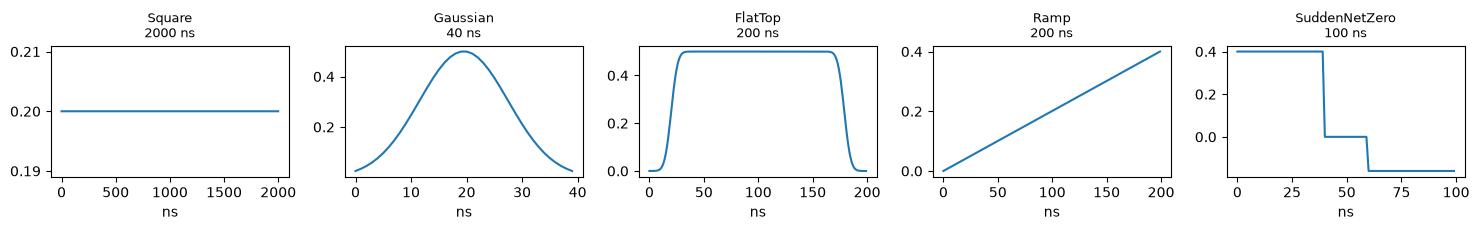

In [10]:
gallery = [
    Square(amplitude=0.2, duration=2000),  # the readout tone
    Gaussian(amplitude=0.5, duration=40, sigma=8),  # a short drive envelope
    FlatTop(amplitude=0.5, duration=200, smooth_duration=20),  # rise, hold, fall
    Ramp(from_amplitude=0.0, to_amplitude=0.4, duration=200),  # a flux excursion
    SuddenNetZero(amplitude=0.4, duration=100, b=0.4, t_phi=20),  # a two-qubit gate pulse
]

fig, axes = plt.subplots(1, len(gallery), figsize=(15, 2.4))
for ax, waveform in zip(axes, gallery, strict=True):
    samples = waveform.envelope()  # one sample per ns at the default resolution
    ax.plot(np.arange(len(samples)), samples)
    ax.set_title(f"{type(waveform).__name__}\n{waveform.get_duration()} ns", fontsize=9)
    ax.set_xlabel("ns")
fig.tight_layout()
plt.show()

The last two are flux shapes, not drive shapes, and nothing in the waveform says so. A `Ramp` is
an envelope and only that. The line you send it down decides what it means, and a flux line is
where these two belong. `BusSchema.transmon()` has no flux bus at all. Part 3 reaches for
`BusSchema.flux_tunable_transmon()` when it starts tuning the qubit with flux.

### IQ waveforms

A drive line is a pair of paths, I and Q, fed through an IQ mixer. An `IQWaveform` carries both, and
`get_I()` / `get_Q()` hand back the two halves as ordinary single-channel waveforms.

`IQDrag` is the standard drive shape: a Gaussian on I, plus its scaled derivative on Q. The
derivative term (`beta`) pushes leakage to the second excited state back down, which is why almost
every real pi pulse is a DRAG pulse and not a plain Gaussian.

Note the two y-axes in the plot. The Q channel is a derivative, so it is antisymmetric and carries a
factor of $1/\sigma$: with `beta=0.15` and `sigma=10` its peak is about a hundred times smaller than
the I peak. Plotted on one axis it would be a flat line at zero.

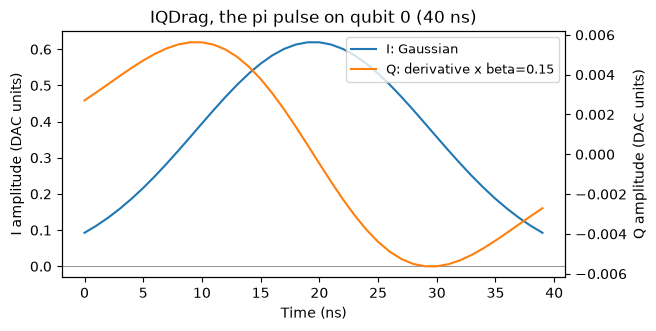

peak I: 0.6192 | peak |Q|: 0.0056


In [11]:
i_samples = pi_pulse.get_I().envelope()
q_samples = pi_pulse.get_Q().envelope()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
(line_i,) = ax.plot(i_samples, label="I: Gaussian")
ax.axhline(0.0, color="grey", linewidth=0.6)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("I amplitude (DAC units)")
ax.set_title(f"IQDrag, the pi pulse on qubit 0 ({pi_pulse.get_duration()} ns)")

twin = ax.twinx()  # Q is ~100x smaller, so give it its own scale
(line_q,) = twin.plot(q_samples, color="tab:orange", label=f"Q: derivative x beta={pi_pulse.beta}")
twin.set_ylabel("Q amplitude (DAC units)")
ax.legend(handles=[line_i, line_q], loc="upper right", fontsize=9)
plt.show()

print("peak I:", round(float(i_samples.max()), 4), "| peak |Q|:", round(float(np.abs(q_samples).max()), 4))

### Structural equality

Waveforms compare and hash by structure, not by identity. Two `Gaussian(0.5, 40, 8)` objects built
in different cells are the same waveform. Whole-program comparison after a file round-trip depends
on that, and so does the equality check in section 1.6.

In [12]:
print("same shape:      ", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 8))
print("one sigma apart: ", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 9))
print("the pi pulse:    ", pi_pulse == IQDrag(DEVICE["q0_a_pi"], 40, 10, 0.15))
print("distinct in a set:", len({Gaussian(0.5, 40, 8), Gaussian(0.5, 40, 8), Gaussian(0.5, 40, 9)}))

same shape:       True
one sigma apart:  False
the pi pulse:     True
distinct in a set: 2


### String aliases: the calibration seam

Look again at the `.qp` text of `drive_program`. The amplitude 0.62 is welded into it. That number
came from a Rabi fit and it will change next Tuesday, which means the program text changes every
time the calibration changes. Every diff is noise.

`play` and `measure` also accept a **string alias** instead of a waveform. The program then says
*which* pulse it wants, and the numbers arrive later from `with_waveforms`. The sequence is the part
you keep under version control; the amplitudes are the part that drifts.

Part 3 fits a real pi pulse and binds it this way, and Part 5 replaces the plain dict below with a
`WaveformLibrary` that resolves a name differently per bus.

In [13]:
aliased = qp.QProgram(label="drive_then_read", schema=schema)
aliased.play(q[0].drive, "pi")  # "whatever a pi pulse is today"
aliased.sync([q[0].drive, q[0].readout])
aliased.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))

print(qp.dumps(aliased).split("body:")[1])  # the body only: the header holds nothing new here

calibration = {"pi": pi_pulse, "readout": readout_pulse, "weights": weights}
bound = aliased.with_waveforms(calibration)  # a new program; `aliased` is untouched
resolved = next(line.strip() for line in qp.dumps(bound).splitlines() if line.strip().startswith("play"))
print("after binding:", resolved)


  play q[0].drive "pi"
  sync q[0].drive q[0].readout
  measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]

after binding: play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)


## 1.5 The program is a tree

Every builder call appended a node. `program.body` is the root `Block`, and `body.elements` is a
plain Python list of its immediate children, in the order you wrote them.

`drive_program` has three top-level children, because the four preparation statements live inside
the `block()`.

In [14]:
print("top-level elements:", len(drive_program.body.elements))
for index, node in enumerate(drive_program.body.elements):
    print(f"  [{index}] {type(node).__name__:<8} buses={sorted(node.buses())}")

top-level elements: 3
  [0] Block    buses=['q0/drive']
  [1] Sync     buses=['q0/drive', 'q0/readout']
  [2] Measure  buses=['q0/readout']


`walk()` is the same tree in pre-order: the root `body` block first, then the `block()` you opened,
then everything inside it, at any depth. One uniform API covers blocks and operations, so you never
write the recursion yourself.

That is the whole reason to keep a program as data. You can compute things about a sequence before
anything runs. The cell below reads how many nanoseconds this program books on the drive line,
straight off the AST. A compiler does a great deal more of this, and so will your own analysis
scripts.

To be clear about where that number comes from, you computed it. The reference simulator has no
timing model at all, so no run will report it back to you. What the AST gives you is the chance to
work it out before you spend fridge time.

In [15]:
print("walk() order:")
for node in drive_program.body.walk():
    print("  ", type(node).__name__)

drive_ns = 0
for node in drive_program.body.walk():
    if isinstance(node, Play) and node.bus == q[0].drive:
        drive_ns += node.waveform.get_duration()
    elif isinstance(node, Wait) and node.bus == q[0].drive:
        drive_ns += node.duration
print("\ntime booked on q[0].drive:", drive_ns, "ns")

walk() order:
   Block
   Block
   SetFrequency
   SetGain
   Play
   Wait
   Sync
   Measure

time booked on q[0].drive: 44 ns


Four more things to know about a built program. One of them is empty on purpose.

In [16]:
print("buses:    ", sorted(drive_program.buses))
print("variables:", drive_program.variables, "<- nothing declared yet, that is Part 2")
print("waveforms:", len(drive_program.body.waveforms()), "distinct")
print("schema:   ", drive_program.schema)

buses:     ['q0/drive', 'q0/readout']
variables: [] <- nothing declared yet, that is Part 2
waveforms: 3 distinct
schema:    BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))


## 1.6 `.qp`, the text format

A program is data, so it serializes. `qp.dumps` writes the `.qp` text format and `qp.loads` reads it
back; `qp.save` and `qp.load` are the same pair against a file.

The format is deliberately boring: one statement per line, indentation for nesting, quoting as the
type distinction (a quoted `"readout_q0"` is a plain string, a bare `q[0].readout` is a bus path).
Nothing is truncated, so a program with 4000 arbitrary samples in it writes 4000 samples. Nothing is
implied, so a file that loads has everything the program had.

The round-trip is exact, and structural equality is how you check it.

In [17]:
out = Path("out")
out.mkdir(exist_ok=True)
path = out / "drive_then_read.qp"

qp.save(drive_program, path)
text = path.read_text()

reloaded = qp.load(path)
print("wrote:", path.resolve(), f"({len(text.splitlines())} lines)")
print("same structure:", reloaded.body == drive_program.body)
print("same text back:", qp.dumps(reloaded) == text)

assert reloaded.body == drive_program.body  # the guarantee, spelled out
assert qp.loads(qp.dumps(drive_program)).body == drive_program.body

wrote: /home/vyron-vasileiadis/projects/qce26-qprogram-tutorial/notebooks/solutions/out/drive_then_read.qp (19 lines)
same structure: True
same text back: True


Why a lab should care about a text format, in three lines:

- **Diffs.** Two calibration runs a week apart differ by a handful of numbers, and a text diff shows
  you exactly which ones. You will do this in Exercise 1.2.
- **Review.** A pulse sequence that a colleague can read in a pull request is a sequence that gets
  checked before it costs fridge time.
- **Reproduction.** The file is the experiment. Six months from now the `.qp` next to your data still
  loads, still carries the measurement names you indexed the results by, and does not depend on the
  notebook that happened to build it.

### 🧩 Exercise 1.1: a two-qubit prepare-and-read

Build one program that excites qubit 0 and qubit 1 and reads both out, then make the schema catch a
mistake.

1. One `QProgram` with `label="prepare_and_read_2q"` and the same `schema`.
2. For each qubit, `set_frequency` its drive bus to `DEVICE["q<i>_f01"]`, then `play` an `IQDrag` at
   `DEVICE["q<i>_a_pi"]` with `duration=40, sigma=10, beta=0.15`.
3. `program.sync()` with no arguments, so both readouts start from the same point in time.
4. `measure` both readout buses, using the `"readout"` and `"weights"` aliases and
   `fields=(MF.IQ, MF.STATE)`. Collect the two handles and print their names.
5. Print `qp.dumps(program)`.
6. Then, inside `try` / `except qp.ValidationError`, measure `q[1].drive` and print the message.

Look at the two handle names in the output. They tell you how per-bus numbering works.

In [ ]:
# TODO: build the two-qubit prepare-and-read sequence.
# 1) two_qubit = qp.QProgram(label="prepare_and_read_2q", schema=schema)
# 2) for i in (0, 1): set_frequency(q[i].drive, DEVICE[f"q{i}_f01"]) then play an IQDrag at
#    DEVICE[f"q{i}_a_pi"] with duration=40, sigma=10, beta=0.15
# 3) two_qubit.sync()
# 4) measure both readout buses with the "readout" / "weights" aliases and
#    fields=(MF.IQ, MF.STATE); keep the handles and print their names
# 5) print(qp.dumps(two_qubit))
# 6) then measure q[1].drive inside try / except qp.ValidationError and print the message

### 🧩 Exercise 1.2: edit the file, load it back, find the change

`out/drive_then_read.qp` is on disk. Retune the pi pulse by hand and prove that exactly one node of
the program moved.

1. Read the file text, and produce an edited copy where `amplitude=0.62` becomes `amplitude=0.31`.
   (In the lab you would open the file in an editor. `str.replace` stands in for that here.)
2. Print a unified diff of the two texts with `difflib.unified_diff`, so you can see the one line
   that changed.
3. `qp.loads` the edited text and confirm the whole body no longer compares equal.
4. Then localise it: compare `body.elements` pairwise, and inside the one child that changed,
   compare its `elements` pairwise too. Exactly one operation should come out different.

Step 4 is the interesting one. Structural equality is not a yes/no answer about a file, it is a
yes/no answer about any node in the tree, and that is how you localise what a colleague changed.

In [ ]:
# TODO: retune the saved program by editing its text.
# 1) original_text = path.read_text(); edited_text = original_text.replace("amplitude=0.62",
#    "amplitude=0.31")
# 2) print a unified diff: difflib.unified_diff(a.splitlines(keepends=True), ..., "a", "b")
# 3) retuned = qp.loads(edited_text); compare retuned.body == drive_program.body
# 4) zip(drive_program.body.elements, retuned.body.elements, strict=True) and report which index
#    changed, then do the same one level down inside .elements[0].elements

## Recap and what is next

- A **bus** is one signal path. Strings work; a `BusSchema` gives you `BusRef`s that are still
  strings but carry `channel` and `acquires`. Those two fields reject a single-channel waveform on
  an IQ line and a `measure` on a bus with no ADC, at the line that made the mistake.
- **Operations** are the verbs: `play`, `measure`, `wait`, `sync`, `set_frequency`, `set_gain`. You
  built a readout tone with an acquisition, and a pi pulse followed by a readout.
- **Waveforms are data.** `envelope()` plots them, structural equality compares them, and a string
  alias leaves the number to be filled in later. That alias is the seam between a stable sequence
  and a drifting calibration.
- **The program is a tree.** `body.elements`, `walk()`, `buses`, `variables`. You read a pulse-time
  budget off the AST before anything ran, the same move a compiler makes.
- **`.qp` is the artifact.** `loads(dumps(p)).body == p.body`, so the file is the experiment, and a
  diff of two files is a diff of two calibrations.

Carry this forward: nothing you wrote in Part 1 said which loop runs on the sequencer and which runs
on the control computer, because there were no loops. Part 2 adds them, together with averaging and
the results that come back.